# **Exercise 4**

In [10]:
import numpy as np


# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
matrix = np.ones((5,5), dtype = int)
matrix[1:4,1:4] = 0
print (matrix)

#Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized_data = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

#Task 3: Implement linear regression solution using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

X_b = np.c_[np.ones((50,1)), X]
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
print("Estimated COEFFICIENTS:", theta_best)
print("True Coefficients:", true_theta)




[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]
Estimated COEFFICIENTS: [-0.01035573  2.51756955 -1.19800274  3.72573182]
True Coefficients: [ 2.5 -1.2  3.7]


# **Exercise 5**

In [17]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major' : np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students), 'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration
# TODO: Display basic information about the dataset
# TODO: Identify and count missing values
# TODO: Fill missing exam_score with the mean score for the student's major
# TODO: Fill missing hours_studied with the median for the student's year

print(df.info())
print("Missing Values:")
print(df.isnull().sum())
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))
df['hours_studied'] = df['hours_studied'].fillna(df['hours_studied'].median())

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major
# TODO: Find the major with the highest average exam_score
# TODO: Calculate the correlation between hours_studied and exam_score
# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70)
avg_scores = df.groupby('major')['exam_score'].mean()
print("\n Average scores by major: \n", avg_scores)
best_major = avg_scores.idxmax()
print("\n Major With Highest Average Exam Score:", best_major)
correlation = df['hours_studied'].corr(df['exam_score'])
print("\n Correlation between Hours Studied and Exam Score;", correlation)

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied
# TODO: Identify top 5 students based on exam_score (handle ties appropriately)
# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns)
grouped = df.groupby(['major']).agg(
    num_students = ('student_id', 'count'),
    avg_exam_score = ('exam_score', 'mean'),
    avg_hours_studied = ('hours_studied', 'mean')
).reset_index()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   exam_score             190 non-null    float64
 3   assignments_completed  200 non-null    int64  
 4   hours_studied          195 non-null    float64
dtypes: float64(2), int64(2), object(1)
memory usage: 7.9+ KB
None
Missing Values:
student_id                0
major                     0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

 Average scores by major: 
 major
Biology    76.101081
CS         77.937491
Math       73.242922
Physics    73.596998
Name: exam_score, dtype: float64

 Major With Highest Average Exam Score: CS

 Correlation between Hours Studied and Exam Score; 0.025628258576929526


# **Exercise 6**

/tmp/ipykernel_15022/1544563835.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='major', y='exam_score', data=df, palette='Set2')


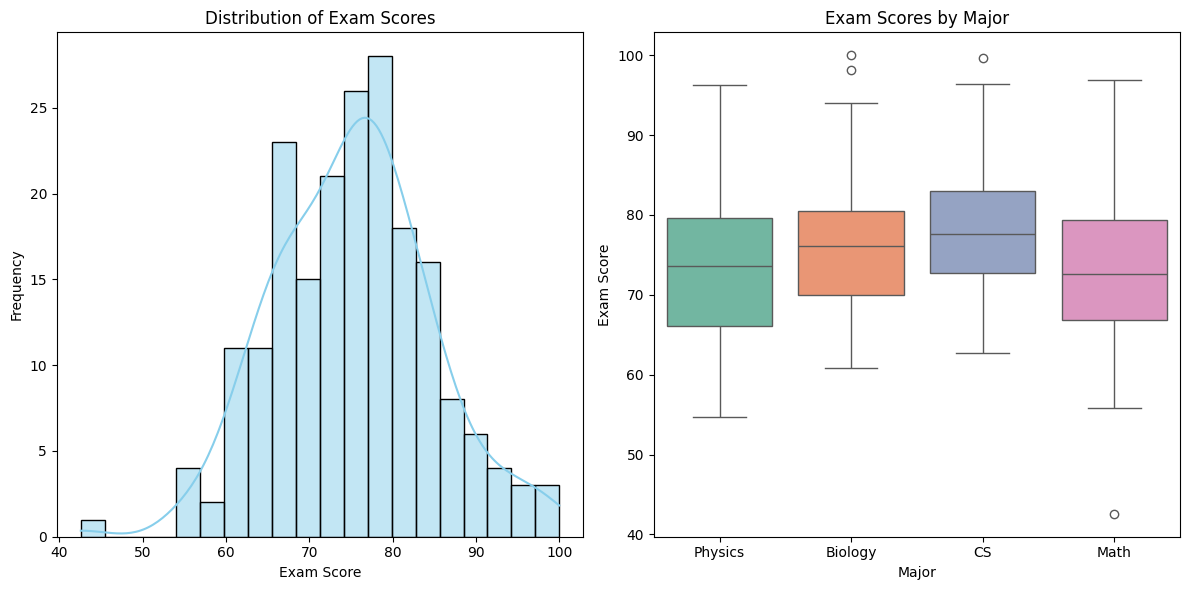

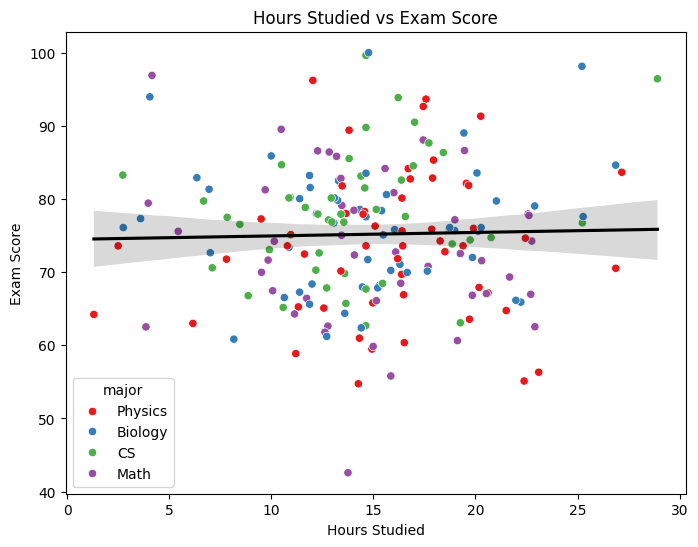

/tmp/ipykernel_15022/1544563835.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='major', y='exam_score', data=df, estimator=np.mean, palette='Set3')
/tmp/ipykernel_15022/1544563835.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='major', data=df, palette = 'Set2')


ValueError: Could not interpret value `performance` for `x`. An entry with this name does not appear in `data`.

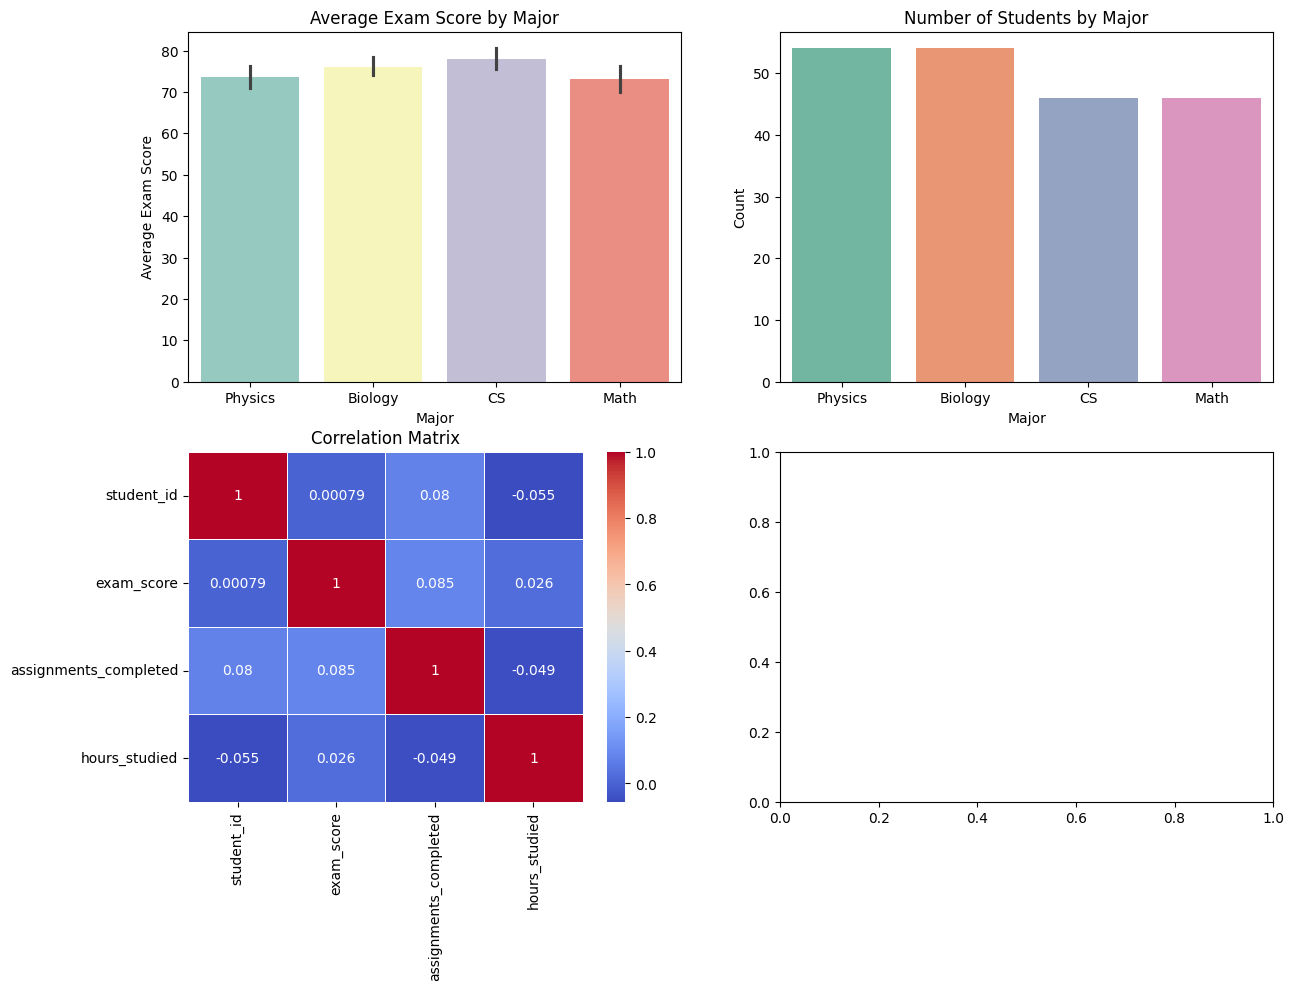

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization (8 points)
# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay
#       Right: Box plot of exam scores by major
# TODO: Add appropriate titles, labels, and styling
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
sns.boxplot(x='major', y='exam_score', data=df, palette='Set2')
plt.title('Exam Scores by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score
# TODO: Color points by major
# TODO: Add a regression line
# TODO: Include appropriate legends, titles, and axis labels

plt.figure(figsize = (8,6))
sns.scatterplot(x = 'hours_studied', y='exam_score', hue = 'major', data = df, palette = 'Set1' )
sns.regplot(x= 'hours_studied', y='exam_score', data = df, scatter = False, color = 'black')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

# Task 3: Advanced Dashboard (9 points)
# TODO: Create a 2x2 subplot figure containing:
#       1. Bar chart: Average exam score by major
#       2. Count plot: Number of students by year
#       3. Heat map: Correlation matrix of numerical columns
#       4. Violin plot: Exam score distribution by performance category
# TODO: Adjust layout, add titles, and ensure readability

plt.figure(figsize=(14,10))
plt.subplot(2, 2, 1)
sns.barplot(x='major', y='exam_score', data=df, estimator=np.mean, palette='Set3')
plt.title('Average Exam Score by Major')
plt.xlabel('Major')
plt.ylabel('Average Exam Score')
plt.subplot(2, 2, 2)
sns.countplot(x='major', data=df, palette = 'Set2')
plt.title('Number of Students by Major')
plt.xlabel('Major')
plt.ylabel('Count')
plt.subplot(2, 2, 3)
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot = True, cmap ='coolwarm', linewidths = 0.5)
plt.title('Correlation Matrix')
plt.subplot(2, 2, 4)
sns.violinplot(x='performance', y='exam_score', data=df, palette = 'Set1')
plt.title('Exam Score Distribution by performance Category')
plt.xlabel('Performance Category')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

### Key Analysis & Recommendations

**Findings:**
- **Top Segment:** The **51-70 age group** currently holds the highest Average CLV and total value, making them the most profitable demographic in this dataset.

**Recommendations:**
1. **Incentivize Frequency:** Implement a loyalty program (e.g., 'Buy 5, Get 1 Free') to shift customers from low-frequency to mid-frequency tiers, as this yields the largest jump in CLV.
2. **Upsell Strategy:** For customers with high income but low CLV, introduce premium subscription tiers to stabilize their 'purchase frequency' and capture more value.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV)
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70
def age_group(age):
    if 18 <= age <= 25:
        return '18-25'
    elif 26 <= age <= 35:
        return '26-35'
    elif 36 <= age <= 50:
        return '36-50'
    else:
        return '51-70'

# TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV

customers['age_group'] = customers['age'].apply(age_group)
age_group_stats = customers.groupby('age_group').agg({
    'customer_id': 'count',
    'income': 'mean',
    'CLV': 'mean'
}).rename(columns={'customer_id': 'num_customers', 'income': 'avg_income', 'CLV': 'avg_clv'})

# TODO: Identify top 10% of customers by CLV
top_10_percent = customers['CLV'].quantile(0.9)
top_customers = customers[customers['CLV'] >= top_10_percent]

# TODO: Create visualizations:
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.scatterplot(data=customers, x='income', y='CLV', hue='age_group')
plt.title('Income vs CLV by Age Group')
plt.subplot(1, 3, 2)
sns.barplot(x=age_group_stats.index, y=age_group_stats['avg_clv'], palette='Set2')
plt.title('Average CLV by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average CLV')

# TODO: Write a brief analysis paragraph (as a markdown cell)
#       summarizing key findings and recommendations
plt.subplot(1, 3, 3)
sns.heatmap(customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()



KeyError: "Column(s) ['customer_id'] do not exist"